In [ ]:
#step 1: imports libe

In [1]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifie

In [ ]:
# step 2: Load Dataset 

In [3]:
df=pd.read_csv("walkrun.csv")

In [4]:
df

,date,time,username,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
0,2017-6-30,13:51:15:847724020,viktor,0,0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-2.9296
1,2017-6-30,13:51:16:246945023,viktor,0,0,0.6722,-1.1233,-0.2344,-0.1757,0.0208,0.1269
2,2017-6-30,13:51:16:446233987,viktor,0,0,0.4399,-1.4817,0.0722,-0.9105,0.1063,-2.4367
3,2017-6-30,13:51:16:646117985,viktor,0,0,0.3031,-0.8125,0.0888,0.1199,-0.4099,-2.9336
4,2017-6-30,13:51:16:846738994,viktor,0,0,0.4814,-0.9312,0.0359,0.0527,0.4379,2.4922
...,...,...,...,...,...,...,...,...,...,...,...
88583,2017-7-9,20:9:15:317911028,viktor,0,0,0.3084,-0.8376,-0.1327,0.4823,2.0124,0.6048
88584,2017-7-9,20:9:15:517889022,viktor,0,0,0.4977,-1.0027,-0.4397,0.1022,-1.2565,-0.0761
88585,2017-7-9,20:9:15:717828989,viktor,0,0,0.4587,-1.1780,-0.2827,-1.4500,-0.2792,-1.2616
88586,2017-7-9,20:9:15:917932987,viktor,0,0,0.2590,-0.8582,-0.0759,-1.5165,0.4560,-1.7755


In [ ]:
# check data shape 

In [5]:
df.shape

(88588, 11)

In [ ]:
# check Data Type

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88588 entries, 0 to 88587
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            88588 non-null  object 
 1   time            88588 non-null  object 
 2   username        88588 non-null  object 
 3   wrist           88588 non-null  int64  
 4   activity        88588 non-null  int64  
 5   acceleration_x  88588 non-null  float64
 6   acceleration_y  88588 non-null  float64
 7   acceleration_z  88588 non-null  float64
 8   gyro_x          88588 non-null  float64
 9   gyro_y          88588 non-null  float64
 10  gyro_z          88588 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 7.4+ MB


In [ ]:
# Check Null Values

In [7]:
df.isnull().sum()

date              0
time              0
username          0
wrist             0
activity          0
acceleration_x    0
acceleration_y    0
acceleration_z    0
gyro_x            0
gyro_y            0
gyro_z            0
dtype: int64

In [5]:
df['activity'].value_counts()

activity
1    44365
0    44223
Name: count, dtype: int64

In [ ]:
# Step 3: Basic EDA

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

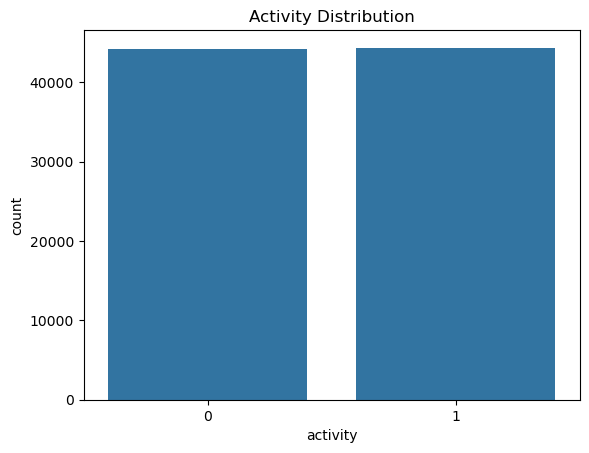

In [7]:
sns.countplot(x='activity', data=df)
plt.title("Activity Distribution")
plt.show()

In [ ]:
# Step 3: Drop Columns

In [9]:
df = df.drop(columns=['date', 'time', 'username'])

In [10]:
df

,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
0,0,0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-2.9296
1,0,0,0.6722,-1.1233,-0.2344,-0.1757,0.0208,0.1269
2,0,0,0.4399,-1.4817,0.0722,-0.9105,0.1063,-2.4367
3,0,0,0.3031,-0.8125,0.0888,0.1199,-0.4099,-2.9336
4,0,0,0.4814,-0.9312,0.0359,0.0527,0.4379,2.4922
...,...,...,...,...,...,...,...,...
88583,0,0,0.3084,-0.8376,-0.1327,0.4823,2.0124,0.6048
88584,0,0,0.4977,-1.0027,-0.4397,0.1022,-1.2565,-0.0761
88585,0,0,0.4587,-1.1780,-0.2827,-1.4500,-0.2792,-1.2616
88586,0,0,0.2590,-0.8582,-0.0759,-1.5165,0.4560,-1.7755


In [ ]:
# Step 5: Train Test split

In [12]:
X = df.drop('activity', axis=1)
y = df['activity']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [16]:
y_train

75300    1
8733     1
1685     1
19098    1
78600    0
        ..
83349    1
58742    1
43188    0
23793    0
81983    1
Name: activity, Length: 70870, dtype: int64

In [ ]:
#Step 6: Use Scalling

In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
# Step 7: Train Multiple Models

In [18]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)


In [ ]:
# Model Evaluation

In [19]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.8639236934191218
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      8845
           1       0.90      0.82      0.86      8873

    accuracy                           0.86     17718
   macro avg       0.87      0.86      0.86     17718
weighted avg       0.87      0.86      0.86     17718



In [ ]:
# Confusion Matrix Visualization

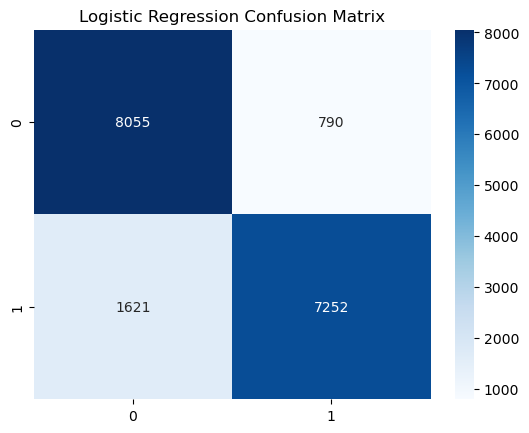

In [20]:
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [ ]:
# Random Forest

In [21]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


In [ ]:
# Model Evaluation

In [22]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Accuracy: 0.9914211536290778
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      8845
           1       0.99      0.99      0.99      8873

    accuracy                           0.99     17718
   macro avg       0.99      0.99      0.99     17718
weighted avg       0.99      0.99      0.99     17718



In [ ]:
# Confusion Matrix Visualization

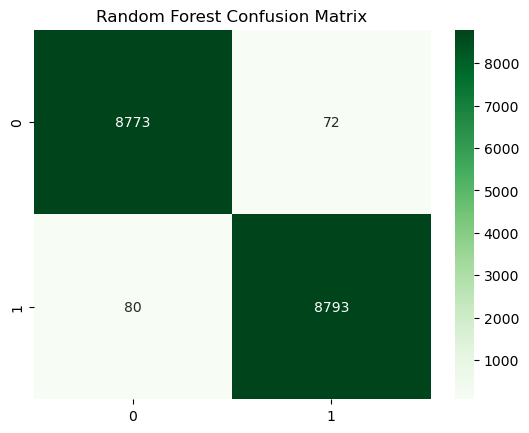

In [23]:
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.show()


In [ ]:
# step 8: Feature Importance

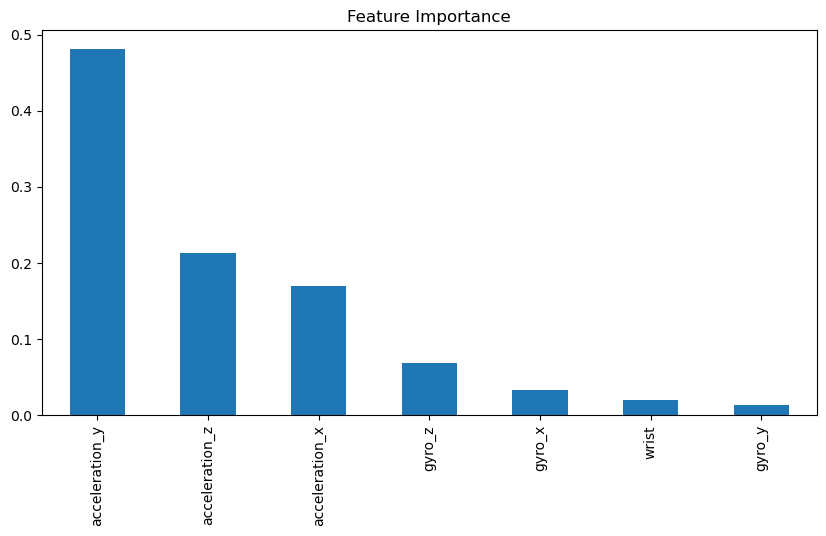

In [24]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=df.drop('activity', axis=1).columns
).sort_values(ascending=False)

feature_importance.plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance")
plt.show()

In [ ]:
# Step 9: Save Model

In [25]:
import joblib

joblib.dump(rf, "activity_classifier.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
# test model (Optional)

In [26]:
sample = np.array([[0, 0.45, -1.1, -0.2, -0.8, 0.3, -2.1]])
sample_scaled = scaler.transform(sample)

rf.predict(sample_scaled)

C:\Users\LAPPKART.COM\Documents\New folder\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0], dtype=int64)

In [27]:
sample_run = np.array([[0, 2.8, -3.5, 1.2, 4.5, -2.1, 6.3]])
sample_run_scaled = scaler.transform(sample_run)

rf.predict(sample_run_scaled)


C:\Users\LAPPKART.COM\Documents\New folder\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([1], dtype=int64)

In [37]:
sample_run = np.array([[0, 0.3, 3.5, -1.2, 4.5, -2.1, 6.3]])
sample_run_scaled = scaler.transform(sample_run)

rf.predict(sample_run_scaled)


C:\Users\LAPPKART.COM\Documents\New folder\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([1], dtype=int64)

In [28]:
sample_run = np.array([[0, 0.45, -1.1, -0.2, -0.8, 0.3, -2.1]])
sample_run_scaled = scaler.transform(sample_run)

rf.predict(sample_run_scaled)

C:\Users\LAPPKART.COM\Documents\New folder\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0], dtype=int64)

In [ ]:
gyro_x = -0.8
gyro_y = 0.3
gyro_z = -2.1